# Testing Our Pipeline of Functions

In [157]:
## So that if you change sth in a src script you don't have to restart the kernel
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [158]:
## Imports
## Allowing for Imports from src folder
import sys
sys.path.append("..") # Adds the project root to the path

In [159]:
## Getting hazard Dict
from src.data_hazard import get_haz_dict

haz_dict = get_haz_dict()

haz_dict

{'TC': {'hazard': <climada.hazard.base.Hazard at 0x300c90230>,
  'impf_set': <climada.entity.impact_funcs.impact_func_set.ImpactFuncSet at 0x300d61d00>}}

In [160]:
hazards = haz_dict.keys()

list(hazards)

['TC']

In [161]:
from src.data_exposure import get_exposure

hazard_types = list(haz_dict.keys())

exposure = get_exposure(hazard_types=hazard_types)

df = exposure.gdf

In [162]:
from src.data_insurance import get_insurance

df["insurance_level"] = get_insurance(insurance_level=0.3)


In [163]:
from src.helpers import comp_impact

df["eai"] = comp_impact(
    haz_dict=haz_dict,
    exposure=exposure
)

2026-04-17 08:52:28,325 - climada.hazard.base - WARNING - Impact function id=1 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.


/Users/arvedluetzen/.pyenv/versions/miniforge3-latest/envs/eth-fs2026-praktikum/lib/python3.12/site-packages/climada/util/lines_polys_handler.py:638: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  group = gdf_pnts.groupby(axis=0, level=0)


In [164]:
from src.helpers import comp_damage_map

df["damaged_area"] = comp_damage_map(
    eai=df["eai"],
    value=df["value"],
    area=df["area"]
)

df

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,impf_TC,geometry,insurance_level,eai,damaged_area
0,01,Ain,Auvergne-Rhône-Alpes,0.199,5762.4,1,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...",0.3,0.000970,1.111779
1,02,Aisne,Hauts-de-France,0.532,7361.7,1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ...",0.3,0.000591,2.316196
2,03,Allier,Auvergne-Rhône-Alpes,0.170,7340.1,1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ...",0.3,0.000862,1.075752
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.025,6925.2,1,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6...",0.3,0.000536,0.092867
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.017,5548.7,1,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ...",0.3,0.000212,0.019975
...,...,...,...,...,...,...,...,...,...,...
91,91,Essonne,Île-de-France,0.403,1804.4,1,"POLYGON ((2.58407 48.67715, 2.58038 48.68948, ...",0.3,0.000700,0.508974
92,92,Hauts-de-Seine,Île-de-France,NaN,175.6,1,"POLYGON ((2.33598 48.93158, 2.33491 48.94154, ...",0.3,0.000649,NaN
93,93,Seine-Saint-Denis,Île-de-France,NaN,236.2,1,"POLYGON ((2.6026 48.92936, 2.6024 48.93532, 2....",0.3,0.000667,NaN
94,94,Val-de-Marne,Île-de-France,0.029,245.0,1,"POLYGON ((2.61482 48.76112, 2.60645 48.77333, ...",0.3,0.000696,0.004942


<Axes: title={'center': 'TC 1: Parabolic temp damage Impact Function'}, xlabel='Intensity (m/s)', ylabel='Impact (%)'>

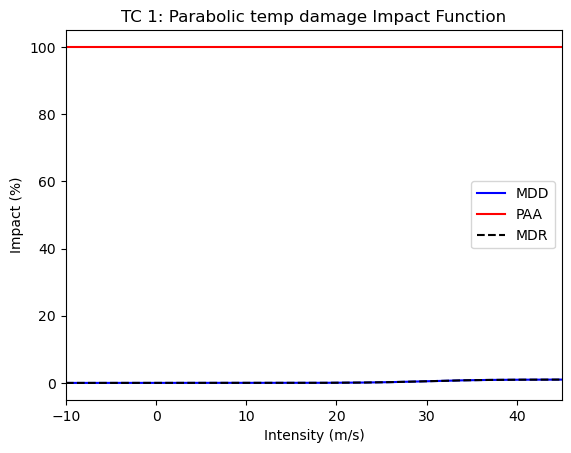

In [166]:
haz_dict["TC"]["impf_set"].plot()

In [165]:
df["eai"]

0     0.000970
1     0.000591
2     0.000862
3     0.000536
4     0.000212
        ...   
91    0.000700
92    0.000649
93    0.000667
94    0.000696
95    0.000605
Name: eai, Length: 96, dtype: float64

In [150]:
comp_who_pays(df["eai"], df["insurance_level"])

,F,I,G
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0
...,...,...,...
91,1.0,0.0,0.0
92,1.0,0.0,0.0
93,1.0,0.0,0.0
94,1.0,0.0,0.0


In [151]:
from src.helpers import comp_who_pays

df = df.join(comp_who_pays(df["eai"], df["insurance_level"]))

In [152]:
## Computing Relative Payments

result = df[['F', 'I', 'G']].mul(df['damaged_area'], axis=0)

df = df.join(result.add_suffix('_area'))

In [153]:
total_damaged_area = df["damaged_area"].sum()

result.sum() / total_damaged_area

F    1.0
I    0.0
G    0.0
dtype: float64

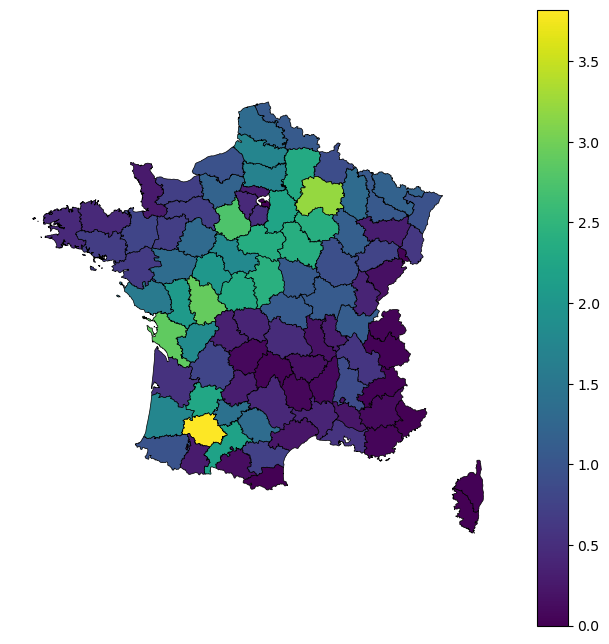

In [154]:
## Plotting Any Column
## Idea: Value (Exposure) x EAI = damaged_area

import geopandas as gpd
import matplotlib.pyplot as plt

# gdf is your GeoDataFrame
# columns: geometry (polygons), value (numeric or categorical)

fig, ax = plt.subplots(figsize=(8, 8))

df.plot(
    column="damaged_area",      # column used for coloring
    ax=ax,
    cmap="viridis",      # color map
    legend=True,         # show color bar / legend
    edgecolor="black",   # polygon borders
    linewidth=0.5
)

ax.set_axis_off()
plt.show()

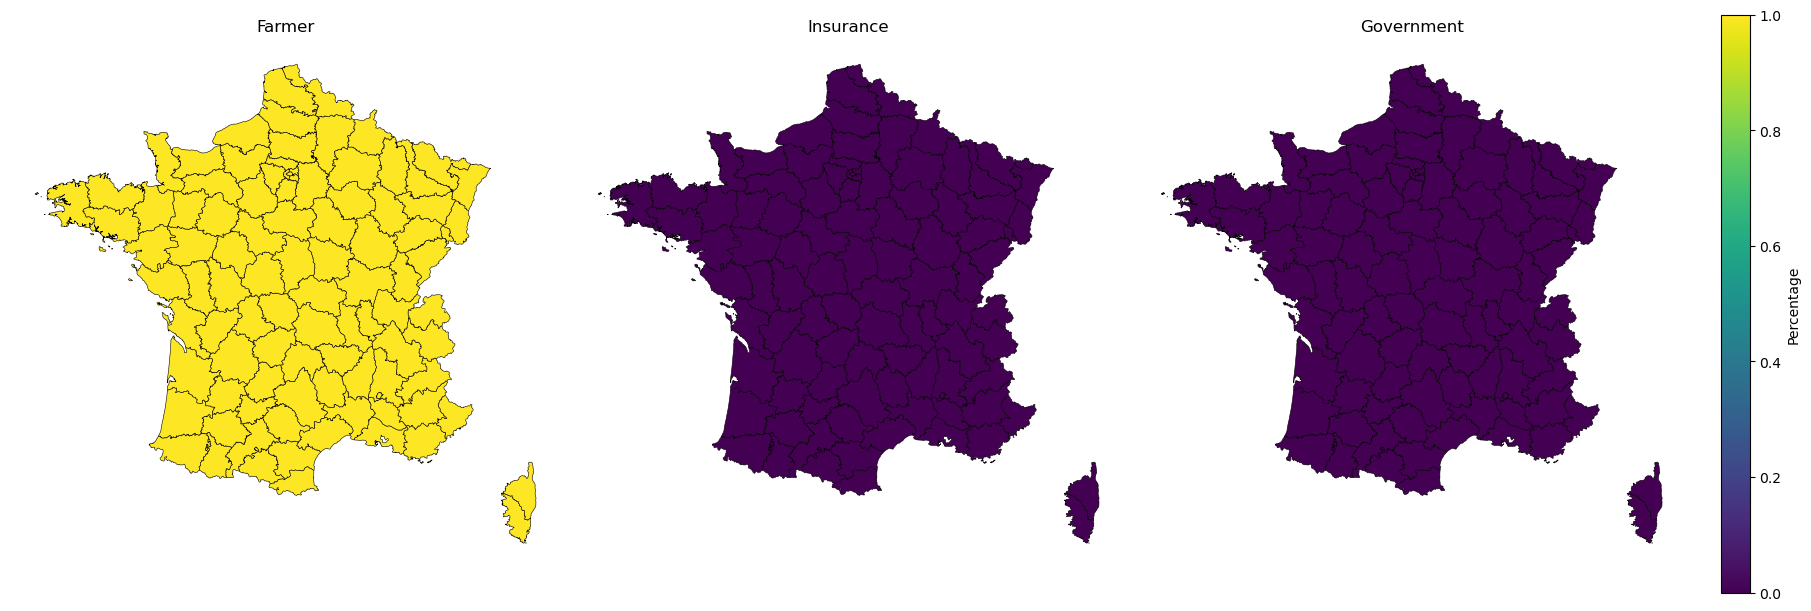

In [155]:
## Plotting
## Who Pays Damaged Area in Percent

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Columns to plot
cols = ["F", "I", "G"]
titles = ["Farmer", "Insurance", "Government"]

# Create figure and axes
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6),
    constrained_layout=True
)

# Shared color normalization (0–1 for percentages)
# Compute global min/max across all three columns
#vmin = df[cols].min().min()
#vmax = df[cols].max().max()
# norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# For Percentages
norm = mpl.colors.Normalize(vmin=0, vmax=1)

cmap = "viridis"

# Plot each column
for ax, col, title in zip(axes, cols, titles):
    df.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        norm=norm,              # ensures shared scale
        edgecolor="black",
        linewidth=0.4
    )
    ax.set_title(title)
    ax.set_axis_off()

# Create a single colorbar
sm = mpl.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)
sm.set_array([])  # required for older matplotlib versions

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)
cbar.set_label("Percentage")

plt.show()

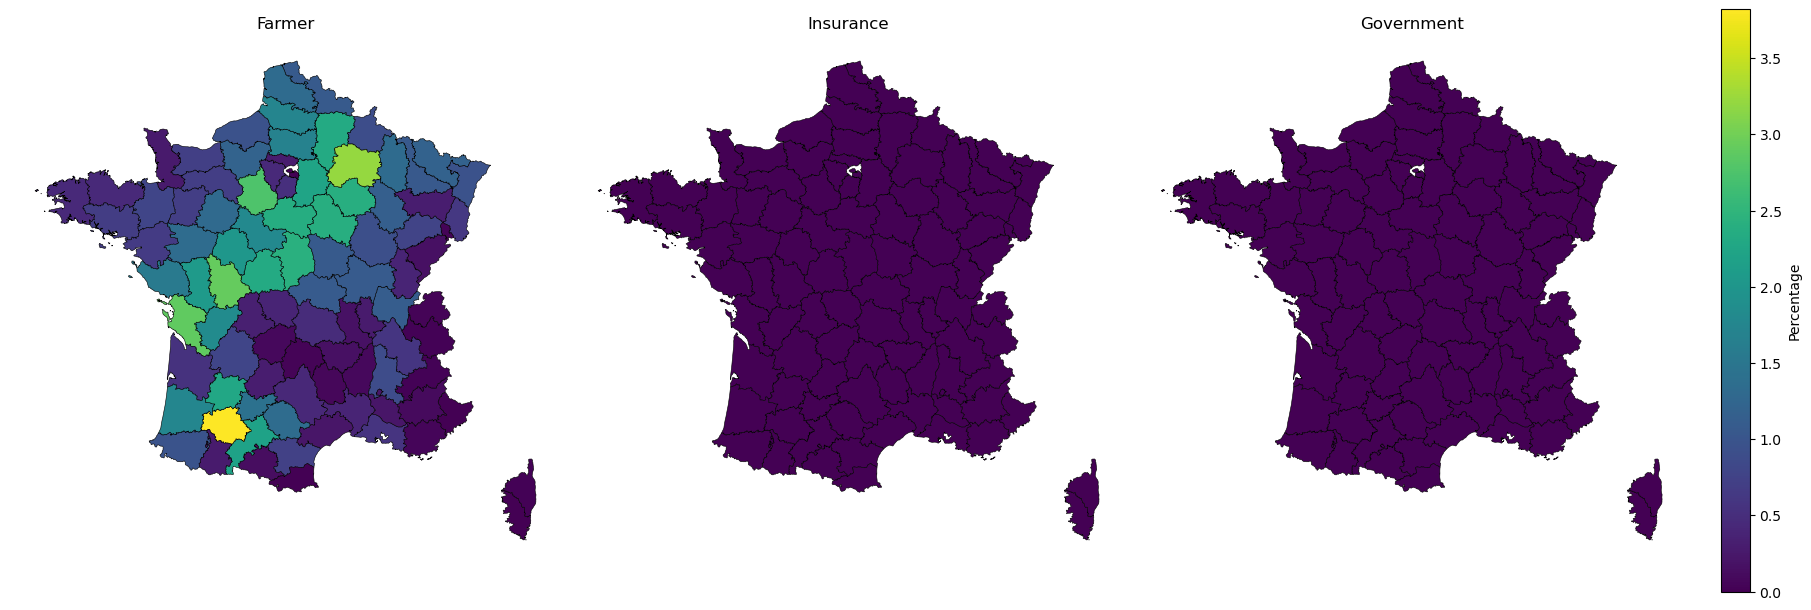

In [156]:
## Plotting
## Who Pays Damaged Area per Deparetement
## Percentage Payed x Damaged Area

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Columns to plot
cols = ["F_area", "I_area", "G_area"]
titles = ["Farmer", "Insurance", "Government"]

# Create figure and axes
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6),
    constrained_layout=True
)

# Shared color normalization (0–1 for percentages)
# Compute global min/max across all three columns
vmin = df[cols].min().min()
vmax = df[cols].max().max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# For Percentages
# norm = mpl.colors.Normalize(vmin=0, vmax=1)

cmap = "viridis"

# Plot each column
for ax, col, title in zip(axes, cols, titles):
    df.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        norm=norm,              # ensures shared scale
        edgecolor="black",
        linewidth=0.4
    )
    ax.set_title(title)
    ax.set_axis_off()

# Create a single colorbar
sm = mpl.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)
sm.set_array([])  # required for older matplotlib versions

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)
cbar.set_label("Percentage")

plt.show()